## SQLite Database using python


In [7]:
import sqlite3
import pandas as pd
import matplotlib.pyplot as plt

# 1. Connect to SQLite database (creates it if it doesn't exist)
conn = sqlite3.connect('sales_data.db')
cursor = conn.cursor()

In [8]:
# 2. Create sales table (if not exists)
cursor.execute('''
    CREATE TABLE IF NOT EXISTS sales (
        id INTEGER PRIMARY KEY,
        product TEXT NOT NULL,
        quantity INTEGER NOT NULL,
        price REAL NOT NULL
    )
''')

In [10]:
sample_data = [
    ('Wireless Mouse', 120, 15.99),
    ('Mechanical Keyboard', 75, 45.50),
    ('USB-C Hub', 60, 22.75),
    ('Laptop Stand', 40, 34.99),
    ('Noise Cancelling Headphones', 30, 89.95),
    ('Webcam HD', 50, 39.90),
    ('Portable SSD 1TB', 25, 99.99),
    ('Bluetooth Speaker', 65, 55.49),
    ('Ergonomic Chair', 15, 199.99),
    ('Monitor 24-inch', 20, 129.99)
]

# Clear old data and insert fresh
cursor.execute('DELETE FROM sales')
cursor.executemany('INSERT INTO sales (product, quantity, price) VALUES (?, ?, ?)', sample_data)
conn.commit()


In [11]:
# 4. Run SQL Query to get total quantity and revenue per product
query = '''
    SELECT product, SUM(quantity) AS total_quantity,
           SUM(quantity * price) AS total_revenue
    FROM sales
    GROUP BY product
'''
df = pd.read_sql_query(query, conn)


In [19]:
# 5. Print output
print("=== Basic Sales Summary ===")
print(df)




=== Basic Sales Summary ===
                       product  total_quantity  total_revenue
0            Bluetooth Speaker              65        3606.85
1              Ergonomic Chair              15        2999.85
2                 Laptop Stand              40        1399.60
3          Mechanical Keyboard              75        3412.50
4              Monitor 24-inch              20        2599.80
5  Noise Cancelling Headphones              30        2698.50
6             Portable SSD 1TB              25        2499.75
7                    USB-C Hub              60        1365.00
8                    Webcam HD              50        1995.00
9               Wireless Mouse             120        1918.80


<Figure size 1000x500 with 0 Axes>

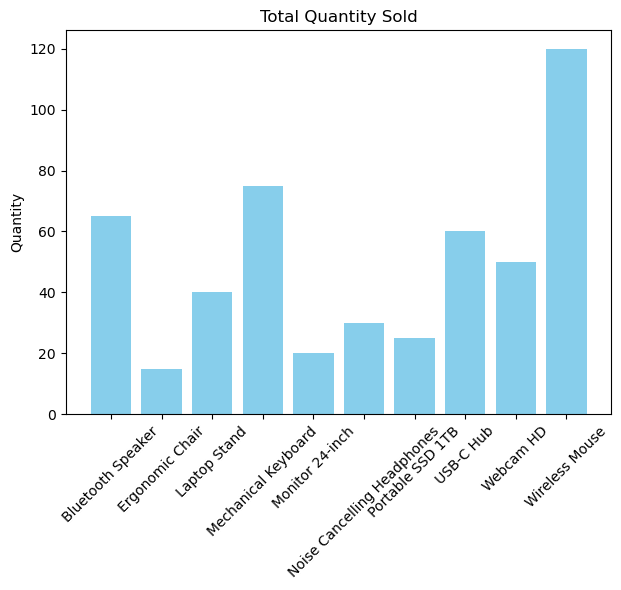

In [20]:
# 6. Plot bar chart for Total Quantity and Revenue
plt.figure(figsize=(10, 5))

plt.figure(figsize=(12, 6))

# Quantity bar plot
plt.subplot(1, 2, 1)
plt.bar(df['product'], df['total_quantity'], color='skyblue')
plt.title('Total Quantity Sold')
plt.ylabel('Quantity')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

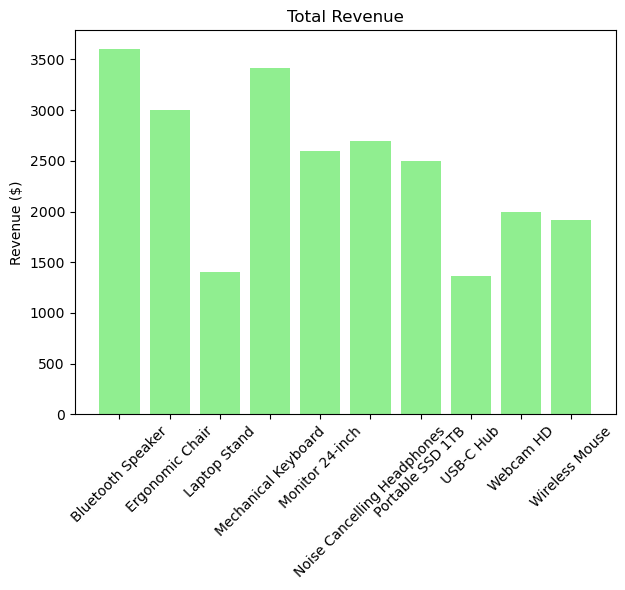

In [22]:
# Revenue bar
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 2)
plt.bar(df['product'], df['total_revenue'], color='lightgreen')
plt.title('Total Revenue')
plt.ylabel('Revenue ($)')
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

# 7. Close the connection
conn.close()